# sac_routing.ipynb — v7 (epoch/episode + per-epoch Yen subgraph)

**Runs from:** `backend/model training/`

### What changed vs v6
1. **Per-epoch Yen subgraph** — `G_ss` is rebuilt every epoch from the **union of top-`YEN_K=30` Yen paths across all agents in that epoch**. The policy only navigates roads that are plausible routes for this epoch's src/dst pairs — same speed guarantee as v5, but generalises because the subgraph rotates every epoch.
2. **`YEN_K = 30`** (was 50 globally; now 30 used both for subgraph and buffer seeding).
3. **`N_EPISODES_PER_EPOCH = 60`** (was 20) — agents get 60 attempts on a fixed pair before pairs rotate, giving solid convergence per pair.
4. **`RouteEnv.set_route(g_policy=...)`** — env reuses object between epochs; updating `g_policy` triggers a fast O(E) adjacency rebuild for the new subgraph.
5. **Flood edges** computed from a fixed 40-pair representative sample (not all 420), keeping startup fast.
6. **21 real Goregaon landmarks**, LON_MAX = 72.900 (Film City), permutation-based epoch schedule — all from v6.

### STATE_DIM = 125 (unchanged)


In [1]:
import os, sys, gc, pickle, time, math, glob, warnings, random
import numpy as np, pandas as pd, networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from collections import deque, defaultdict, Counter
from itertools import islice, permutations as _perms
from pathlib import Path
import torch, torch.nn as nn, torch.nn.functional as F
from torch.distributions import Categorical
warnings.filterwarnings('ignore')

# Resolve repository root robustly regardless of notebook launch directory.
PROJECT_ROOT = None
for cand in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (cand / 'backend').exists() and (cand / 'requirements.txt').exists():
        PROJECT_ROOT = cand
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd().resolve()

DATA_DIR = PROJECT_ROOT / 'backend' / 'data generation' / 'data'
GRAPH_PATH  = DATA_DIR / 'graph' / 'mumbai.graphml'
STATIC_PATH = DATA_DIR / 'static' / 'edges_static.parquet'
TS_DIR      = DATA_DIR / 'timeseries'
PRED_DIR    = DATA_DIR / 'predictions'

# Prediction inputs priority:
# 1) GWN cache pickle (ttr.pkl), 2) generic predictions parquet (horizon_tplus_*.parquet)
GWN_PRED_CANDIDATES = [
    PRED_DIR / 'gwn' / 'ttr.pkl',
    PROJECT_ROOT / 'backend' / 'models' / 'gwn' / 'ttr.pkl',
]
SCALER_CANDIDATES = [
    DATA_DIR / 'scalers' / 'scaler_ttr.pkl',
    PROJECT_ROOT / 'backend' / 'models' / 'gwn' / 'scaler_ttr.pkl',
]
PRED_PATH  = next((p for p in GWN_PRED_CANDIDATES if p.exists()), GWN_PRED_CANDIDATES[0])
SCALER_TTR = next((p for p in SCALER_CANDIDATES if p.exists()), SCALER_CANDIDATES[0])
PRED_PARQUET_GLOB = str(PRED_DIR / 'horizon_tplus_*.parquet')
GWN_TTR_MODEL = PROJECT_ROOT / 'backend' / 'models' / 'gwn' / 'best_ttr.pt'

OUT_DIR   = PROJECT_ROOT / 'backend' / 'models' / 'sac_routing'
VIZ_ASTAR = OUT_DIR / 'viz' / 'astar'
VIZ_SAC   = OUT_DIR / 'viz' / 'sac'
CKPT_DIR  = OUT_DIR / 'checkpoints'
ARTIFACTS = OUT_DIR / 'artifacts'
for d in [VIZ_ASTAR, VIZ_SAC, CKPT_DIR, ARTIFACTS]: os.makedirs(d, exist_ok=True)

print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'GWN cache candidate = {PRED_PATH}')
print(f'GWN scaler candidate = {SCALER_TTR}')
print(f'Predictions parquet glob = {PRED_PARQUET_GLOB}')

# ── Bounding box (extended east to include Film City / Aarey Colony) ─────────
LAT_MIN, LAT_MAX = 19.13,  19.20
LON_MIN, LON_MAX = 72.82,  72.900   # was 72.88; extended for Film City (72.888)

START_HOUR        = 8
START_DAY_OF_WEEK = 0
FLOOD_CONG        = 0.70
# YEN_K: top-k shortest paths per agent — used BOTH for building the per-epoch
# subgraph (G_ss) AND for seeding the replay buffer. 30 paths comfortably covers
# all realistic detour corridors while keeping per-epoch setup under ~5 s.
YEN_K             = 30

MAX_NEIGHBORS = 8
STATE_GLOBAL  = 14
STATE_CUREDGE = 7
STATE_PER_NB  = 13
STATE_DIM     = STATE_GLOBAL + STATE_CUREDGE + MAX_NEIGHBORS * STATE_PER_NB   # 14+7+104=125
ACTION_DIM    = MAX_NEIGHBORS
MAX_FFS_KMH_CAP = 120.0
ROAD_TYPE_MAX   = 8.0

MIN_MAX_STEPS    = 150
ASTAR_STEP_MULT  = 3
STALL_STEPS      = 30
CYCLE_VISIT_CAP  = 5

# ── Epoch / episode structure ─────────────────────────────────────────────────
# src/dst per agent is FIXED within an epoch, CHANGES between epochs.
# All 21 locations yield up to 21×20=420 ordered pairs.
# Each epoch pulls N_AGENTS distinct pairs (no shared src or dst within epoch).
N_EPOCHS             = 50   # number of epochs (src/dst rotates every epoch)
N_EPISODES_PER_EPOCH = 60   # episodes with the SAME src/dst per agent per epoch
N_AGENTS             = 9    # simultaneous agents (each with different pair)
VIZ_EVERY_EP         = 10   # global episode interval for visualisation

BUFFER_SIZE  = 200_000
BATCH_SIZE   = 256
WARMUP_STEPS = 1_000
GOAL_BIAS    = 0.70
LR           = 3e-4
GAMMA        = 0.99
TAU          = 0.005
HIDDEN       = 384
TARGET_ENT_SCALE = 0.5
MASK_LOGIT   = -1e4
GRAD_CLIP    = 5.0
ALPHA_CLAMP  = 1.0

R_PROGRESS          =   3.0
R_TIME              = - 0.4
R_CONG_ACTUAL       = - 2.0
R_CONG_PRED_DEVIATE =   0.8
R_FLOODED           = - 2.0
R_REVISIT_BASE      = - 1.0
R_DEADEND           = - 20.0
R_FALLBACK_TRIGGER  = - 25.0
R_GOAL              = 250.0
R_GOAL_TIME         =   4.0

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
rng = random.Random(SEED)   # independent RNG for epoch schedule
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'STATE_DIM={STATE_DIM} | HIDDEN={HIDDEN} | YEN_K={YEN_K} (subgraph+seed)')
print(f'N_EPOCHS={N_EPOCHS} | N_EPISODES_PER_EPOCH={N_EPISODES_PER_EPOCH} | N_AGENTS={N_AGENTS}')
print(f'Total agent-episodes: {N_EPOCHS * N_EPISODES_PER_EPOCH * N_AGENTS:,}')


PROJECT_ROOT = E:\Projects\Major 2.0\Mumbai-Traffic-Prediction-and-Navigation-using-Deep-Learning
GWN cache candidate = E:\Projects\Major 2.0\Mumbai-Traffic-Prediction-and-Navigation-using-Deep-Learning\backend\data generation\data\predictions\gwn\ttr.pkl
GWN scaler candidate = E:\Projects\Major 2.0\Mumbai-Traffic-Prediction-and-Navigation-using-Deep-Learning\backend\data generation\data\scalers\scaler_ttr.pkl
Predictions parquet glob = E:\Projects\Major 2.0\Mumbai-Traffic-Prediction-and-Navigation-using-Deep-Learning\backend\data generation\data\predictions\horizon_tplus_*.parquet
Device: cuda
STATE_DIM=125 | HIDDEN=384 | YEN_K=30 (subgraph+seed)
N_EPOCHS=50 | N_EPISODES_PER_EPOCH=60 | N_AGENTS=9
Total agent-episodes: 27,000


In [2]:
# ─── GWN cache bootstrap (no model inference in this notebook) ────────────────
# Keep SAC logic unchanged: this notebook consumes a prebuilt cache file.
# Expected schema: {'values': np.ndarray[E,168,1], 'edge_ids': List[str]}
PRED_EXPORT_PATH = DATA_DIR / 'predictions' / 'gwn' / 'ttr.pkl'
PRED_EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)

if PRED_PATH.exists():
    print(f'Using existing GWN cache: {PRED_PATH}')
else:
    print('[INFO] GWN cache not found here yet:')
    print(f'       {PRED_PATH}')
    print('       Run train_gwn_v3 export cell to generate ttr.pkl')


[INFO] GWN cache not found here yet:
       E:\Projects\Major 2.0\Mumbai-Traffic-Prediction-and-Navigation-using-Deep-Learning\backend\data generation\data\predictions\gwn\ttr.pkl
       Run train_gwn_v3 export cell to generate ttr.pkl


In [3]:
print('Loading mumbai.graphml ...'); t0 = time.perf_counter()
import osmnx as ox
G_full = ox.load_graphml(GRAPH_PATH)
print(f'  {G_full.number_of_nodes():,} nodes  {G_full.number_of_edges():,} edges  ({time.perf_counter()-t0:.1f}s)')

edges_static_full = pd.read_parquet(STATIC_PATH)
u_caster = type(edges_static_full['u'].iloc[0])
def _cast(n):
    try: return u_caster(n)
    except Exception: return n

nodes_in_set = set(); node_coords = {}
for n, d in G_full.nodes(data=True):
    lat, lon = float(d['y']), float(d['x'])
    if LAT_MIN <= lat <= LAT_MAX and LON_MIN <= lon <= LON_MAX:
        nc = _cast(n); nodes_in_set.add(nc); node_coords[nc] = (lat, lon)
print(f'  nodes in bbox: {len(nodes_in_set):,}')

edges_df = edges_static_full[
    edges_static_full['u'].isin(nodes_in_set) &
    edges_static_full['v'].isin(nodes_in_set)
].reset_index(drop=True)
print(f'  static edges in bbox: {len(edges_df):,}')
if len(edges_df) == 0: raise RuntimeError('Zero edges — dtype mismatch?')

edges_df['free_flow_travel_time'] = (
    edges_df['road_length'] / (edges_df['free_flow_speed'] * 1000 / 3600)
).clip(lower=0.5).astype(np.float32)
if 'signals_per_km' not in edges_df.columns:
    edges_df['signals_per_km'] = (
        edges_df['traffic_signal_count'] / (edges_df['road_length']/1000).clip(lower=0.01)
    ).astype(np.float32)
def parse_key(eid):
    parts = eid.rsplit('_', 1)
    try: return int(parts[1])
    except Exception: return 0
edges_df['key_parsed'] = edges_df['edge_id'].map(parse_key).astype(np.int32)

G_geo = nx.MultiDiGraph()
for n in nodes_in_set:
    G_geo.add_node(n, y=node_coords[n][0], x=node_coords[n][1])
for row in edges_df.itertuples(index=False):
    G_geo.add_edge(row.u, row.v, key=int(row.key_parsed))
print(f'  G_geo: {G_geo.number_of_nodes():,} nodes, {G_geo.number_of_edges():,} edges')

edge_len       = dict(zip(edges_df['edge_id'], edges_df['road_length'].astype(np.float32)))
edge_ffs       = dict(zip(edges_df['edge_id'], edges_df['free_flow_speed'].astype(np.float32)))
edge_fftt      = dict(zip(edges_df['edge_id'], edges_df['free_flow_travel_time'].astype(np.float32)))
edge_roadtype  = dict(zip(edges_df['edge_id'], edges_df['road_type_enc'].astype(np.float32)))
edge_lanes     = dict(zip(edges_df['edge_id'], edges_df['num_lanes'].astype(np.float32)))
edge_signals   = dict(zip(edges_df['edge_id'], edges_df['signals_per_km'].astype(np.float32)))
edge_corridor  = dict(zip(edges_df['edge_id'], edges_df['corridor_id'].astype(np.int32)))

max_ffs_kmh = float(edges_df['free_flow_speed'].max())
max_ffs_ms  = max_ffs_kmh * 1000 / 3600
max_signals = float(max(edges_df['signals_per_km'].max(), 1.0))
print(f'  max_ffs {max_ffs_kmh:.1f} km/h  max_sig/km {max_signals:.2f}')
del edges_static_full, G_full; gc.collect()


Loading mumbai.graphml ...
  62,674 nodes  145,265 edges  (14.5s)
  nodes in bbox: 3,953
  static edges in bbox: 9,065
  G_geo: 3,953 nodes, 9,065 edges
  max_ffs 80.0 km/h  max_sig/km 200.00


442061

In [4]:
preds_values, pred_eid2gi, scaler_ttr = None, None, None
pred_path = Path(PRED_PATH)
scaler_path = Path(SCALER_TTR)
gwn_preds_are_scaled = False
pred_source = 'none'

if pred_path.exists():
    with open(pred_path, 'rb') as f:
        preds = pickle.load(f)
    preds_values = np.asarray(preds['values'], dtype=np.float32)
    if preds_values.ndim == 2:
        preds_values = preds_values[..., None]
    pred_eid2gi = {str(e): i for i, e in enumerate(preds['edge_ids'])}
    pred_source = 'gwn_cache_pkl'

    if scaler_path.exists():
        with open(scaler_path, 'rb') as f:
            scaler_ttr = pickle.load(f)
        gwn_preds_are_scaled = True
        print(f'Loaded GWN predictions (scaled): {preds_values.shape}')
        print(f'  cache={pred_path}')
        print(f'  scaler={scaler_path}')
    else:
        # Support cache exports that already store de-normalized TTR values.
        print(f'Loaded GWN predictions (assumed de-normalized): {preds_values.shape}')
        print(f'  cache={pred_path}')
        print('  scaler missing -> using cache values directly')
else:
    # Fallback source: generic predictions parquet files in data/predictions
    # Expected columns: edge_id, base_timestamp, pred_ttr
    # Process file-by-file to avoid high memory usage.
    parquet_files = sorted(glob.glob(PRED_PARQUET_GLOB))
    if parquet_files:
        edge_ids = [str(e) for e in edges_df['edge_id'].tolist()]
        pred_eid2gi = {eid: i for i, eid in enumerate(edge_ids)}
        sums = np.zeros((len(edge_ids), 168), dtype=np.float64)
        cnts = np.zeros((len(edge_ids), 168), dtype=np.int32)
        week_start = pd.Timestamp('2024-07-01 00:00:00')
        n_ok = 0

        for pf in parquet_files:
            try:
                dfp = pd.read_parquet(pf, columns=['edge_id', 'base_timestamp', 'pred_ttr'])
            except Exception:
                continue
            if len(dfp) == 0:
                continue

            dfp['edge_id'] = dfp['edge_id'].astype(str)
            dfp = dfp[dfp['edge_id'].isin(pred_eid2gi)]
            if len(dfp) == 0:
                continue

            ts = pd.to_datetime(dfp['base_timestamp'])
            dfp['hour'] = ((ts - week_start).dt.total_seconds() // 3600).clip(0, 167).astype(np.int32)
            g = dfp.groupby(['edge_id', 'hour'], as_index=False)['pred_ttr'].agg(['sum', 'count']).reset_index()

            for row in g.itertuples(index=False):
                gi = pred_eid2gi[str(row.edge_id)]
                h = int(row.hour)
                sums[gi, h] += float(row.sum)
                cnts[gi, h] += int(row.count)
            n_ok += 1

        if n_ok > 0:
            preds_values = np.full((len(edge_ids), 168, 1), np.nan, dtype=np.float32)
            mask = cnts > 0
            preds_values[..., 0][mask] = (sums[mask] / cnts[mask]).astype(np.float32)
            pred_source = 'predictions_parquet'
            print(f'Loaded predictions parquet: {n_ok}/{len(parquet_files)} files')
            print(f'  matrix shape={preds_values.shape}')
    if pred_source == 'none':
        print('[INFO] Running with raw TTR fallback (no prediction cache found).')
        print('  SAC routing logic remains unchanged; only GWN prediction input is unavailable.')
        if Path(GWN_TTR_MODEL).exists():
            print(f'  model checkpoint present: {GWN_TTR_MODEL}')
            print('  to enable GWN predictions, place ttr.pkl or horizon_tplus_*.parquet under data/predictions')

print('Loading raw TTR + cong (vectorized) ...'); t0 = time.perf_counter()
goreg_eid_set = set(edges_df['edge_id'])
eid_to_local  = {e: i for i, e in enumerate(edges_df['edge_id'])}
raw_ttr     = np.full((len(edges_df), 168), 1.0, dtype=np.float32)
actual_cong = np.full((len(edges_df), 168), 0.0, dtype=np.float32)
week_start  = pd.Timestamp('2024-07-01 00:00:00')
for bf in sorted(glob.glob(f'{TS_DIR}/batch_*.parquet')):
    df = pd.read_parquet(bf, columns=['edge_id','timestamp','travel_time_ratio','congestion_level'])
    df = df[df['edge_id'].isin(goreg_eid_set)]
    if len(df) == 0: del df; continue
    ts  = pd.to_datetime(df['timestamp'])
    hrs = ((ts - week_start).dt.total_seconds() // 3600).clip(0,167).astype(np.int32).values
    lis = df['edge_id'].map(eid_to_local).values.astype(np.int32)
    raw_ttr[lis, hrs]     = df['travel_time_ratio'].values.astype(np.float32)
    actual_cong[lis, hrs] = df['congestion_level'].values.astype(np.float32)
    del df; gc.collect()
print(f'  raw_ttr     {raw_ttr.min():.3f}/{raw_ttr.mean():.3f}/{raw_ttr.max():.3f}')
print(f'  actual_cong {actual_cong.min():.3f}/{actual_cong.mean():.3f}/{actual_cong.max():.3f}')
print(f'  done in {time.perf_counter()-t0:.1f}s')

def get_pred_ttr(eid, hour):
    hour = max(0, min(166, int(hour)))
    if preds_values is not None and eid in pred_eid2gi:
        gi = pred_eid2gi[eid]
        v = preds_values[gi, hour, 0]
        if not np.isnan(v):
            if gwn_preds_are_scaled and scaler_ttr is not None:
                return float(max(1.0, v * scaler_ttr.scale_[0] + scaler_ttr.mean_[0]))
            return float(max(1.0, v))
    li = eid_to_local.get(eid)
    if li is None: return 1.0
    return float(max(1.0, raw_ttr[li, min(hour+1, 167)]))

def get_actual_cong(eid, hour):
    hour = max(0, min(167, int(hour)))
    li = eid_to_local.get(eid)
    if li is None: return 0.0
    return float(actual_cong[li, hour])

def get_pred_cong(eid, hour):
    ttr = get_pred_ttr(eid, hour)
    return float(max(0.0, min(0.97, 1.0 - 1.0/max(ttr, 1.0))))


Loaded predictions parquet: 12/12 files
  matrix shape=(9065, 168, 1)
Loading raw TTR + cong (vectorized) ...
  raw_ttr     1.000/1.331/10.000
  actual_cong 0.000/0.213/0.970
  done in 10.8s


In [5]:
# ─── Geometry helpers ─────────────────────────────────────────────────────────
def haversine_km(a, b):
    lat1, lon1 = a; lat2, lon2 = b
    R = 6371.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp, dl = math.radians(lat2-lat1), math.radians(lon2-lon1)
    h = math.sin(dp/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dl/2)**2
    return 2*R*math.asin(math.sqrt(h))

def bearing(a, b):
    if a == b: return 0.0
    lat1, lon1 = math.radians(a[0]), math.radians(a[1])
    lat2, lon2 = math.radians(b[0]), math.radians(b[1])
    dlon = lon2 - lon1
    x = math.sin(dlon)*math.cos(lat2)
    y = math.cos(lat1)*math.sin(lat2) - math.sin(lat1)*math.cos(lat2)*math.cos(dlon)
    return math.atan2(x, y)

_coord_keys = list(node_coords.keys())
_coord_arr  = np.array([node_coords[n] for n in _coord_keys], dtype=np.float32)
def nearest_node(lat, lon):
    d = (_coord_arr[:,0]-lat)**2 + (_coord_arr[:,1]-lon)**2
    return _coord_keys[int(np.argmin(d))]

def edge_travel_time_sec(eid, cong):
    ffs = edge_ffs.get(eid, 30.0)
    speed_ms = max(0.5, ffs * (1 - cong) * 1000/3600)
    return edge_len.get(eid, 50.0) / speed_ms

# ─── 21 Goregaon landmark coordinates ─────────────────────────────────────────
# Coordinates are kept within bbox (lat 19.13-19.20, lon 72.82-72.90).
# Updated clearly-off points using Goregaon-bounded geocode matches.
GOREGAON_LOCATIONS = [
    # (name,                        lat,      lon)
    ('Goregaon East',               19.1693, 72.8553),
    ('Goregaon West',               19.1633, 72.8412),
    ('Aarey Colony',                19.1645, 72.8610),
    ('Film City',                   19.1510, 72.8870),  # kept (ambiguous geocode results)
    ('Oberoi Mall',                 19.1735, 72.8600),
    ('Inorbit Mall Goregaon',       19.1740, 72.8360),
    ('Goregaon Railway Station',    19.1647, 72.8493),
    ('Nesco IT Park',               19.1525, 72.8550),
    ('Nirlon Knowledge Park',       19.1548, 72.8534),
    ('Royal Palms Estate',          19.1425, 72.8830),
    ('Bangur Nagar',                19.1685, 72.8330),
    ('Jawahar Nagar',               19.1625, 72.8430),
    ('Unnat Nagar',                 19.1720, 72.8385),
    ('Motilal Nagar',               19.1589, 72.8403),
    ('Pandurang Wadi',              19.1720, 72.8507),
    ('Dindoshi',                    19.1760, 72.8650),
    ('St Xaviers High School',      19.1715, 72.8420),
    ('Vibgyor High School',         19.1595, 72.8359),
    ('SRV Hospital Goregaon',       19.1680, 72.8465),
    ('Lifeline Medicare Hospital',  19.1605, 72.8480),
    ('St Johns High School',        19.1673, 72.8456),
]
N_LOCATIONS = len(GOREGAON_LOCATIONS)

# Snap each landmark to its nearest graph node
LOC_NODES = []
print(f'Snapping {N_LOCATIONS} landmarks to graph nodes:')
for name, lat, lon in GOREGAON_LOCATIONS:
    node = nearest_node(lat, lon)
    actual = node_coords[node]
    dist_m = haversine_km((lat, lon), actual) * 1000
    LOC_NODES.append({'name': name, 'lat': lat, 'lon': lon,
                      'node': node, 'xy': actual})
    print(f'  {name:<35s} → node {node}  snap={dist_m:.0f}m')

# All ordered pairs of distinct location indices (permutations of 2)
ALL_LOC_PAIRS = [
    (i, j) for i, j in _perms(range(N_LOCATIONS), 2)
    if LOC_NODES[i]['node'] != LOC_NODES[j]['node']
]
print(f'\nTotal valid location pairs (src≠dst node): {len(ALL_LOC_PAIRS)}')

AGENT_COLORS = ['#e6194b','#3cb44b','#4363d8','#f58231','#911eb4',
                '#42d4f4','#f032e6','#9a6324','#800000']


Snapping 21 landmarks to graph nodes:
  Goregaon East                       → node 1712508422  snap=102m
  Goregaon West                       → node 4357109779  snap=16m
  Aarey Colony                        → node 5968879585  snap=179m
  Film City                           → node 5968353192  snap=71m
  Oberoi Mall                         → node 10211936520  snap=49m
  Inorbit Mall Goregaon               → node 11991486843  snap=30m
  Goregaon Railway Station            → node 1169472512  snap=77m
  Nesco IT Park                       → node 4611106873  snap=77m
  Nirlon Knowledge Park               → node 10310503648  snap=198m
  Royal Palms Estate                  → node 7363083856  snap=303m
  Bangur Nagar                        → node 1919874073  snap=59m
  Jawahar Nagar                       → node 4362415516  snap=8m
  Unnat Nagar                         → node 4347106977  snap=232m
  Motilal Nagar                       → node 10927904434  snap=60m
  Pandurang Wadi              

In [6]:
# ─── Epoch schedule generator ─────────────────────────────────────────────────
# Produces N_EPOCHS batches of N_AGENTS pairs.
# Within each epoch: all agents have different src AND different dst.
# Pairs rotate across epochs so the policy is forced to generalise.

def generate_epoch_schedule(n_epochs, n_agents, all_pairs, seed=42):
    """
    Returns a list of length n_epochs.
    Each element is a list of n_agents (src_loc_idx, dst_loc_idx) tuples.
    Within an epoch no two agents share the same src index or dst index,
    ensuring diverse concurrent routes.
    """
    rng_local = random.Random(seed)
    pool = list(all_pairs)
    rng_local.shuffle(pool)
    schedule = []
    ptr = 0

    for ep_idx in range(n_epochs):
        chosen = []
        used_src, used_dst = set(), set()
        scanned = 0
        pool_len = len(pool)

        # First pass: strict — no shared src OR dst within epoch
        while len(chosen) < n_agents and scanned < pool_len:
            pair = pool[(ptr + scanned) % pool_len]
            si, di = pair
            if si not in used_src and di not in used_dst:
                chosen.append(pair)
                used_src.add(si); used_dst.add(di)
            scanned += 1
        ptr = (ptr + scanned) % pool_len

        # Fallback: relax dst uniqueness if pool is too small
        if len(chosen) < n_agents:
            for pair in pool:
                if pair not in chosen:
                    si, di = pair
                    if si not in used_src:
                        chosen.append(pair); used_src.add(si)
                        if len(chosen) == n_agents: break

        # Re-shuffle pool every full cycle to vary the sequence across epochs
        if ptr < scanned % pool_len:
            rng_local.shuffle(pool)

        schedule.append(chosen[:n_agents])

    return schedule

EPOCH_SCHEDULE = generate_epoch_schedule(N_EPOCHS, N_AGENTS, ALL_LOC_PAIRS, seed=SEED)
print(f'Epoch schedule: {N_EPOCHS} epochs × {N_AGENTS} agents')
print('Sample epoch assignments:')
for ep_idx in [0, 1, N_EPOCHS//2, N_EPOCHS-1]:
    pairs_str = ', '.join(
        f"{GOREGAON_LOCATIONS[s][0].split()[0]}→{GOREGAON_LOCATIONS[d][0].split()[0]}"
        for s, d in EPOCH_SCHEDULE[ep_idx])
    print(f'  Epoch {ep_idx+1:2d}: {pairs_str}')

# Verify coverage: how many unique pairs are visited across all epochs?
all_used = set()
for sched in EPOCH_SCHEDULE:
    for pair in sched: all_used.add(pair)
print(f'\nUnique pairs used across {N_EPOCHS} epochs: {len(all_used)}/{len(ALL_LOC_PAIRS)}')


Epoch schedule: 50 epochs × 9 agents
Sample epoch assignments:
  Epoch  1: Jawahar→Pandurang, Vibgyor→St, Unnat→Nirlon, Goregaon→Unnat, Pandurang→Motilal, Royal→St, Nesco→Bangur, St→Goregaon, Lifeline→Vibgyor
  Epoch  2: Unnat→Goregaon, Goregaon→Bangur, Pandurang→Nirlon, Aarey→Goregaon, St→Motilal, Vibgyor→Goregaon, Film→Royal, Nesco→St, SRV→Pandurang
  Epoch 26: St→Bangur, Nirlon→Motilal, Inorbit→Jawahar, Film→St, Lifeline→Inorbit, Vibgyor→SRV, Oberoi→Goregaon, Goregaon→Oberoi, Nesco→Aarey
  Epoch 50: Motilal→Goregaon, Goregaon→St, Lifeline→Jawahar, Oberoi→Royal, Unnat→Aarey, Nirlon→Bangur, Film→Lifeline, Goregaon→Oberoi, Bangur→Inorbit

Unique pairs used across 50 epochs: 319/420


In [7]:
# ─── Build DiGraph for Yen k-shortest paths ───────────────────────────────────
def build_digraph_with_weights(G_multi, start_hour=START_HOUR):
    DG = nx.DiGraph(); best = {}
    for u, v, k in G_multi.edges(keys=True):
        eid = f'{u}_{v}_{k}'
        if eid not in edge_fftt: continue
        w = get_pred_ttr(eid, start_hour) * edge_fftt[eid]
        cur = best.get((u, v))
        if cur is None or w < cur[1]: best[(u, v)] = (k, w)
    for (u, v), (k, w) in best.items():
        DG.add_edge(u, v, weight=w, key=k)
    return DG, best

def k_shortest_paths_yen(DG, src, dst, k):
    try: return list(islice(nx.shortest_simple_paths(DG, src, dst, weight='weight'), k))
    except nx.NetworkXNoPath: return []

def nodes_to_edges(node_path, uv_to_key):
    return [(u, v, uv_to_key[(u, v)][0]) for u, v in zip(node_path[:-1], node_path[1:])]

print('Projecting DiGraph for Yen ...')
DG, uv_best = build_digraph_with_weights(G_geo, start_hour=START_HOUR)
print(f'  DG: {DG.number_of_nodes():,} nodes, {DG.number_of_edges():,} edges')


Projecting DiGraph for Yen ...
  DG: 3,941 nodes, 9,001 edges


In [8]:
# ─── Time-dependent A* ────────────────────────────────────────────────────────
from heapq import heappush, heappop

def tda_star(G, src, dst, start_hour=START_HOUR, start_elapsed_sec=0.0):
    dst_xy = node_coords[dst]
    def h(n): return haversine_km(node_coords[n], dst_xy) * 1000 / max_ffs_ms
    open_heap = [(h(src), 0, 0.0, src, None)]
    came_from = {src: (None, None)}; best_g = {src: 0.0}; tiebr = 0
    while open_heap:
        f, _, g, u, _ = heappop(open_heap)
        if u == dst: break
        if g > best_g.get(u, float('inf')): continue
        cur_hr = start_hour + int((g + start_elapsed_sec) // 3600)
        for _, v, k, _ in G.out_edges(u, keys=True, data=True):
            eid = f'{u}_{v}_{k}'
            if eid not in edge_fftt: continue
            w = get_pred_ttr(eid, cur_hr) * edge_fftt[eid]
            ng = g + w
            if ng < best_g.get(v, float('inf')):
                best_g[v] = ng; came_from[v] = (u, (u,v,k)); tiebr += 1
                heappush(open_heap, (ng + h(v), tiebr, ng, v, (u,v,k)))
    if dst not in came_from or best_g.get(dst, float('inf')) == float('inf'):
        return None, float('inf')
    path = []; cur = dst
    while cur != src:
        par, edge = came_from[cur]
        path.append(edge); cur = par
    path.reverse()
    return path, best_g[dst]


In [9]:
# ─── Flood edges: representative 40-pair sample (fast, ~10-20 s) ─────────────
# flood_edges are pinned to FLOOD_CONG during the whole training run to simulate
# a realistic flood scenario on Goregaon's main arteries.
# We sample 40 evenly-spaced ordered pairs from ALL_LOC_PAIRS for coverage.
# The per-epoch subgraph (G_ss_epoch) is built separately inside the epoch loop
# using the CURRENT epoch's agents' Yen paths — see build_epoch_subgraph().

N_FLOOD_PAIRS = 40
step = max(1, len(ALL_LOC_PAIRS) // N_FLOOD_PAIRS)
FLOOD_SAMPLE_PAIRS = ALL_LOC_PAIRS[::step][:N_FLOOD_PAIRS]

print(f'Pre-computing flood_edges from {len(FLOOD_SAMPLE_PAIRS)} representative pairs ...')
t0 = time.perf_counter()
flood_edges = set()
for si, di in FLOOD_SAMPLE_PAIRS:
    src_node = LOC_NODES[si]['node']; dst_node = LOC_NODES[di]['node']
    path, _ = tda_star(G_geo, src_node, dst_node, START_HOUR)
    if path is not None:
        for e in path: flood_edges.add(e)
print(f'  flood_edges={len(flood_edges):,}  ({time.perf_counter()-t0:.1f}s)')

flood_overlay = {}
for (u,v,k) in flood_edges:
    eid = f'{u}_{v}_{k}'
    flood_overlay[eid] = max(get_actual_cong(eid, START_HOUR), FLOOD_CONG)

def cong_with_flood(eid, hour):
    if eid in flood_overlay: return flood_overlay[eid]
    return get_actual_cong(eid, hour)

# Corridor index for local congestion feature
corridor_to_lis = defaultdict(list)
for li, row in enumerate(edges_df.itertuples(index=False)):
    corridor_to_lis[int(row.corridor_id)].append(li)
for cid in corridor_to_lis:
    corridor_to_lis[cid] = np.array(corridor_to_lis[cid], np.int32)

def mean_local_cong(node, hour):
    h = max(0, min(167, int(hour)))
    cids = set()
    for _, v, k in G_geo.out_edges(node, keys=True):
        eid = f'{node}_{v}_{k}'
        if eid in edge_corridor: cids.add(int(edge_corridor[eid]))
    if not cids: return 0.0
    vals = []
    for cid in cids:
        lis = corridor_to_lis.get(cid)
        if lis is None or len(lis) == 0: continue
        vals.append(float(actual_cong[lis, h].mean()))
    return float(np.mean(vals)) if vals else 0.0

# ─── Per-epoch subgraph builder ───────────────────────────────────────────────
def build_epoch_subgraph(agents):
    """
    Build a MultiDiGraph from the UNION of all Yen-path edges (+ A* edges) of
    every agent in this epoch.  This is the policy graph G_ss_epoch that agents
    navigate during the episode loop.  It is compact (only plausible roads for
    the current src/dst pairs) yet rotates every epoch, forcing generalisation.

    Typical size: 300-800 edges for 9 agents with YEN_K=30.
    """
    epoch_edges = set()
    for ag in agents:
        for e in ag['astar_path']: epoch_edges.add(e)
        for yp in ag['yen_paths_ranked']:
            for e in yp: epoch_edges.add(e)
    G_sub = nx.MultiDiGraph()
    for (u, v, k) in epoch_edges:
        if u not in G_sub.nodes: G_sub.add_node(u, y=node_coords[u][0], x=node_coords[u][1])
        if v not in G_sub.nodes: G_sub.add_node(v, y=node_coords[v][0], x=node_coords[v][1])
        G_sub.add_edge(u, v, key=k)
    return G_sub, epoch_edges

MAX_DIST_KM = haversine_km((LAT_MIN, LON_MIN), (LAT_MAX, LON_MAX))
print(f'MAX_DIST_KM = {MAX_DIST_KM:.2f}')
print('flood_edges and epoch subgraph builder ready.')


Pre-computing flood_edges from 40 representative pairs ...
  flood_edges=303  (0.3s)
MAX_DIST_KM = 11.45
flood_edges and epoch subgraph builder ready.


In [10]:
# ─── Visualisation helpers ────────────────────────────────────────────────────
def _is_peak_hour(h_of_day):
    return 1.0 if ((7 <= h_of_day <= 10) or (17 <= h_of_day <= 20)) else 0.0

def _draw_background(ax, show_flood=True, epoch_edges=None):
    for u, v, k in G_geo.edges(keys=True):
        ya, xa = node_coords[u]; yb, xb = node_coords[v]
        ax.plot([xa, xb], [ya, yb], color='#dddddd', linewidth=0.4, zorder=1)
    # Highlight the current epoch's subgraph edges in blue if provided
    if epoch_edges:
        for (u, v, k) in epoch_edges:
            ya, xa = node_coords[u]; yb, xb = node_coords[v]
            ax.plot([xa, xb], [ya, yb], color='#8aa0b5', linewidth=0.8, alpha=0.6, zorder=2)
    if show_flood:
        for (u, v, k) in flood_edges:
            ya, xa = node_coords[u]; yb, xb = node_coords[v]
            ax.plot([xa, xb], [ya, yb], color='#d62728', linewidth=1.2,
                    linestyle='--', alpha=0.55, zorder=3)
    ax.set_xlim(LON_MIN, LON_MAX); ax.set_ylim(LAT_MIN, LAT_MAX)
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_aspect(1/math.cos(math.radians(19.17)))

def _draw_route(ax, edge_list, color, lw=2.5, alpha=1.0, linestyle='-'):
    xs, ys = [], []
    for (u, v, _) in edge_list:
        ya, xa = node_coords[u]; yb, xb = node_coords[v]
        xs += [xa, xb, None]; ys += [ya, yb, None]
    ax.plot(xs, ys, color=color, linewidth=lw, alpha=alpha,
            zorder=5, solid_capstyle='round', linestyle=linestyle)

def _draw_markers(ax, src_xy, dst_xy, color):
    ax.scatter([src_xy[1]], [src_xy[0]], marker='o', s=90, c=color,
               edgecolors='black', linewidths=1.2, zorder=7)
    ax.scatter([dst_xy[1]], [dst_xy[0]], marker='*', s=220, c=color,
               edgecolors='black', linewidths=1.2, zorder=7)

def _draw_landmark_labels(ax):
    for loc in LOC_NODES:
        ax.annotate(loc['name'], xy=(loc['xy'][1], loc['xy'][0]),
                    fontsize=5, ha='center', color='#333333', zorder=8)

# Draw all-landmarks overview
fig, ax = plt.subplots(figsize=(13, 11))
_draw_background(ax, show_flood=True, epoch_edges=None)
for loc in LOC_NODES:
    ax.scatter([loc['xy'][1]], [loc['xy'][0]], marker='D', s=50,
               c='#ff7f0e', edgecolors='black', linewidths=0.8, zorder=8)
    ax.annotate(loc['name'], xy=(loc['xy'][1], loc['xy'][0]),
                xytext=(3, 3), textcoords='offset points', fontsize=5.5, zorder=9)
ax.set_title('Goregaon landmarks + state-space edges (blue) + flood edges (red-dashed)', fontsize=10)
plt.tight_layout()
plt.savefig(f'{VIZ_ASTAR}/landmarks_overview.png', dpi=120, bbox_inches='tight')
plt.close(fig)
print(f'Saved → {VIZ_ASTAR}/landmarks_overview.png')


Saved → E:\Projects\Major 2.0\Mumbai-Traffic-Prediction-and-Navigation-using-Deep-Learning\backend\models\sac_routing\viz\astar/landmarks_overview.png


In [11]:
# ─── RouteEnv ─────────────────────────────────────────────────────────────────
class RouteEnv:
    """
    Navigation environment for a single agent.

    Key change vs v5: set_route() allows updating src/dst between epochs
    without reinstantiating the object.  G_policy = G_geo (full graph) so
    agents generalise beyond Yen-cached corridors.
    """
    def __init__(self, G_policy, G_full, src, dst, policy_steps, astar_edges_set,
                 start_hour=START_HOUR, start_dow=START_DAY_OF_WEEK):
        self.G_policy = G_policy; self.G_full = G_full
        self.start_hour = start_hour; self.start_dow = start_dow
        self._tda_cache = {}
        # Delegate route-specific state to set_route
        self.src = self.dst = None  # set below
        self.set_route(src, dst, astar_edges_set, policy_steps)

    # ── Route update (called once per epoch per agent) ────────────────────────
    def set_route(self, src, dst, astar_edges_set, policy_steps, g_policy=None):
        """Assign a new src/dst pair and (optionally) a new policy subgraph.
        Rebuilds adjacency tables and resets episode state."""
        if g_policy is not None:
            self.G_policy = g_policy
        self.src, self.dst = src, dst
        self.src_xy = node_coords[src]; self.dst_xy = node_coords[dst]
        self.total_straight_km = haversine_km(self.src_xy, self.dst_xy)
        self.astar_edges_set = astar_edges_set
        self.policy_steps = policy_steps
        # Rebuild adj sorted by distance to NEW destination
        self._adj_pol  = self._build_adj(self.G_policy)
        self._adj_full = self._build_adj(self.G_full)
        self._tda_cache = {}
        return self.reset()

    def _build_adj(self, G):
        adj = {}
        for n in G.nodes():
            edges = list(G.out_edges(n, keys=True))
            edges.sort(key=lambda e: haversine_km(node_coords[e[1]], self.dst_xy))
            adj[n] = edges[:MAX_NEIGHBORS]
        return adj

    def _neighbors_policy(self): return self._adj_pol.get(self.node, [])

    def action_mask(self):
        m = np.zeros(MAX_NEIGHBORS, dtype=bool)
        m[:len(self._neighbors_policy())] = True
        if not m.any(): m[0] = True
        return m

    def reset(self):
        self.node = self.src
        self.visited = {self.src}
        self.visit_count = Counter([self.src])
        self.elapsed_sec = 0.0
        self.policy_step_count = 0
        self.total_steps = 0
        self.edges_taken = []
        self.cum_reward = 0.0
        self.done = False; self.reached = False; self.reached_by_policy = False
        self.fallback_fired = False; self.fallback_reason = None
        self.best_dist = haversine_km(self.src_xy, self.dst_xy)
        self.no_progress_steps = 0
        self.last_edge = None
        return self._get_state()

    def _tda_remaining_min(self):
        hour = self.start_hour + int(self.elapsed_sec // 3600)
        key = (self.node, hour)
        if key in self._tda_cache: return self._tda_cache[key]
        path, t_sec = tda_star(self.G_full, self.node, self.dst,
                               self.start_hour, start_elapsed_sec=self.elapsed_sec)
        val = (t_sec/60.0) if path is not None else (self.best_dist * 60/max_ffs_kmh)
        val = float(min(val, 120.0))
        self._tda_cache[key] = val
        return val

    def _edge_actual_cong(self, u, v, k, hour):
        """Apply flood only on this agent's A* corridor edges."""
        eid = f'{u}_{v}_{k}'
        if (u, v, k) in self.astar_edges_set and eid in flood_overlay:
            return flood_overlay[eid]
        return get_actual_cong(eid, hour)

    def _current_edge_features(self):
        if self.last_edge is None:
            return np.zeros(STATE_CUREDGE, dtype=np.float32)
        u, v, k = self.last_edge; eid = f'{u}_{v}_{k}'
        hour = self.start_hour + int(self.elapsed_sec // 3600)
        pred_ttr  = get_pred_ttr(eid, hour)
        pred_cong = get_pred_cong(eid, hour)
        act_cong  = self._edge_actual_cong(u, v, k, hour)
        act_t_min = edge_travel_time_sec(eid, act_cong) / 60.0
        ffs       = edge_ffs.get(eid, 30.0)
        length_km = edge_len.get(eid, 50.0) / 1000.0
        rt_enc    = edge_roadtype.get(eid, 1.0)
        return np.array([
            min((pred_ttr - 1.0) / 4.0, 1.0),
            min(act_t_min / 10.0, 1.0),
            pred_cong, act_cong,
            min(ffs / MAX_FFS_KMH_CAP, 1.0),
            min(length_km / 2.0, 1.0),
            rt_enc / ROAD_TYPE_MAX,
        ], dtype=np.float32)

    def _neighbor_features(self):
        nb = np.zeros((MAX_NEIGHBORS, STATE_PER_NB), dtype=np.float32)
        nbrs = self._neighbors_policy()
        cur_xy = node_coords[self.node]
        brg_goal = bearing(cur_xy, self.dst_xy)
        hour = self.start_hour + int(self.elapsed_sec // 3600)
        for i, (u, v, k) in enumerate(nbrs):
            eid = f'{u}_{v}_{k}'; nxy = node_coords[v]
            pred_ttr   = get_pred_ttr(eid, hour)
            pred_cong  = get_pred_cong(eid, hour)
            act_cong   = self._edge_actual_cong(u, v, k, hour)
            act_t_min  = edge_travel_time_sec(eid, act_cong) / 60.0
            ffs        = edge_ffs.get(eid, 30.0)
            length_km  = edge_len.get(eid, 50.0) / 1000.0
            rt_enc     = edge_roadtype.get(eid, 1.0)
            sig_per_km = edge_signals.get(eid, 0.0)
            is_astar   = 1.0 if (u, v, k) in self.astar_edges_set else 0.0
            rem_d      = haversine_km(nxy, self.dst_xy)
            nb_brg     = bearing(cur_xy, nxy)
            align      = math.cos(brg_goal - nb_brg)
            visited_f  = 1.0 if v in self.visited else 0.0
            flooded_f  = 1.0 if ((u, v, k) in self.astar_edges_set and (u, v, k) in flood_edges) else 0.0
            nb[i] = [
                min((pred_ttr - 1.0) / 4.0, 1.0),
                min(act_t_min / 10.0, 1.0),
                pred_cong, act_cong,
                min(ffs / MAX_FFS_KMH_CAP, 1.0),
                min(length_km / 2.0, 1.0),
                rt_enc / ROAD_TYPE_MAX,
                min(sig_per_km / max_signals, 1.0),
                is_astar,
                min(rem_d / MAX_DIST_KM, 1.0),
                align, visited_f, flooded_f,
            ]
        return nb

    def _global_features(self):
        cur_xy = node_coords[self.node]
        d_km = haversine_km(cur_xy, self.dst_xy)
        brg = bearing(cur_xy, self.dst_xy)
        hour_float = self.start_hour + self.elapsed_sec / 3600.0
        h_of_day   = int(hour_float) % 24
        day_of_wk  = (self.start_dow + int(hour_float) // 24) % 7
        minute     = (self.elapsed_sec / 60.0) % 1440.0
        tod_sin = math.sin(2*math.pi * minute / 1440.0)
        tod_cos = math.cos(2*math.pi * minute / 1440.0)
        dow_sin = math.sin(2*math.pi * day_of_wk / 7.0)
        dow_cos = math.cos(2*math.pi * day_of_wk / 7.0)
        is_peak = _is_peak_hour(h_of_day)
        mean_c  = mean_local_cong(self.node, int(hour_float))
        tda_min = self._tda_remaining_min()
        progress = min(1.0, max(0.0,
            (self.total_straight_km - d_km) / max(self.total_straight_km, 1e-3)))
        return np.array([
            min(d_km / MAX_DIST_KM, 1.0),
            math.sin(brg), math.cos(brg),
            min(self.elapsed_sec / 3600.0, 2.0),
            self.policy_step_count / max(self.policy_steps, 1),
            len(self._neighbors_policy()) / MAX_NEIGHBORS,
            tod_sin, tod_cos, dow_sin, dow_cos,
            is_peak, mean_c,
            min(tda_min / 60.0, 2.0),
            progress,
        ], dtype=np.float32)

    def _get_state(self):
        g  = self._global_features()
        ce = self._current_edge_features()
        nb = self._neighbor_features().ravel()
        s  = np.concatenate([g, ce, nb]).astype(np.float32)
        s  = np.nan_to_num(s, nan=0.0, posinf=10.0, neginf=-10.0)
        return np.clip(s, -10.0, 10.0)

    def _execute_edge(self, u, v, k, *, from_policy=True, add_fallback_trigger=False):
        eid = f'{u}_{v}_{k}'
        cur_xy = node_coords[self.node]
        prev_d = haversine_km(cur_xy, self.dst_xy)
        hour_now = self.start_hour + int(self.elapsed_sec // 3600)
        pred_cong = get_pred_cong(eid, hour_now)
        act_cong  = self._edge_actual_cong(u, v, k, hour_now)
        et_sec = edge_travel_time_sec(eid, act_cong)
        self.node = v; self.elapsed_sec += et_sec; self.total_steps += 1
        if from_policy: self.policy_step_count += 1
        self.edges_taken.append((u, v, k)); self.last_edge = (u, v, k)
        new_d = haversine_km(node_coords[v], self.dst_xy)
        r  = R_PROGRESS * (prev_d - new_d)
        r += R_TIME * (et_sec / 60.0)
        r += R_CONG_ACTUAL * act_cong
        if pred_cong > act_cong:
            r += R_CONG_PRED_DEVIATE * (pred_cong - act_cong)
        if (u, v, k) in self.astar_edges_set and (u, v, k) in flood_edges: r += R_FLOODED
        prior_count = self.visit_count.get(v, 0)
        self.visit_count[v] = prior_count + 1
        if prior_count >= 1:
            r += R_REVISIT_BASE * min(prior_count, 3)
        if v not in self.visited: self.visited.add(v)
        if add_fallback_trigger: r += R_FALLBACK_TRIGGER
        if v == self.dst:
            bonus = max(0.0, (30.0 - self.elapsed_sec/60.0)) * R_GOAL_TIME
            r += R_GOAL + bonus
            self.done = True; self.reached = True
            if from_policy and not self.fallback_fired:
                self.reached_by_policy = True
        if new_d < self.best_dist - 0.02:
            self.best_dist = new_d; self.no_progress_steps = 0
        else:
            self.no_progress_steps += 1
        self.cum_reward += r
        return r

    def _should_fallback(self):
        if self.fallback_fired: return False, None
        if self.policy_step_count >= self.policy_steps: return True, 'budget_exhausted'
        if self.no_progress_steps >= STALL_STEPS: return True, 'stalled'
        if max(self.visit_count.values()) >= CYCLE_VISIT_CAP: return True, 'cycle'
        if len(self._neighbors_policy()) == 0: return True, 'deadend_in_subgraph'
        return False, None

    def fire_fallback(self, reason):
        self.fallback_fired = True; self.fallback_reason = reason
        path, _ = tda_star(self.G_full, self.node, self.dst,
                           self.start_hour, start_elapsed_sec=self.elapsed_sec)
        if path is None or len(path) == 0:
            self.done = True; self.cum_reward += R_DEADEND * 5
            return []
        return path

    def step(self, action: int):
        nbrs = self._neighbors_policy()
        if action >= len(nbrs) or len(nbrs) == 0:
            self.cum_reward += R_DEADEND
            return self._get_state(), R_DEADEND, False, {
                'force_fallback': True, 'reason': 'invalid_action_or_deadend'}
        u, v, k = nbrs[action]
        r = self._execute_edge(u, v, k, from_policy=True)
        info = {}
        if self.done:
            return self._get_state(), r, True, info
        should, reason = self._should_fallback()
        if should:
            info['force_fallback'] = True; info['reason'] = reason
            self.cum_reward += R_FALLBACK_TRIGGER
            r += R_FALLBACK_TRIGGER
        return self._get_state(), r, False, info


In [12]:
# ─── Neural networks + replay buffer + SAC ────────────────────────────────────
class QNet(nn.Module):
    def __init__(self, sd, ad, hid=HIDDEN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(sd, hid), nn.ReLU(),
            nn.Linear(hid, hid), nn.ReLU(),
            nn.Linear(hid, hid), nn.ReLU(),
            nn.Linear(hid, ad))
    def forward(self, s): return self.net(s)

class PolicyNet(nn.Module):
    def __init__(self, sd, ad, hid=HIDDEN):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(sd, hid), nn.ReLU(),
            nn.Linear(hid, hid), nn.ReLU(),
            nn.Linear(hid, hid), nn.ReLU())
        self.head = nn.Linear(hid, ad)
    def forward(self, s, mask=None):
        h = self.trunk(s)
        logits = torch.clamp(self.head(h), -20.0, 20.0)
        if mask is not None:
            logits = torch.where(mask, logits, torch.full_like(logits, MASK_LOGIT))
        return logits

class ReplayBuffer:
    def __init__(self, cap, sd, ad):
        self.cap = cap; self.ptr = 0; self.size = 0
        self.s  = np.zeros((cap, sd), np.float32); self.a = np.zeros(cap, np.int64)
        self.r  = np.zeros(cap, np.float32); self.s2 = np.zeros((cap, sd), np.float32)
        self.d  = np.zeros(cap, np.float32); self.m = np.zeros((cap, ad), np.bool_)
        self.m2 = np.zeros((cap, ad), np.bool_)
    def push(self, s, a, r, s2, d, m, m2):
        s  = np.nan_to_num(s,  nan=0.0, posinf=10.0, neginf=-10.0)
        s2 = np.nan_to_num(s2, nan=0.0, posinf=10.0, neginf=-10.0)
        r  = float(np.clip(np.nan_to_num(r, nan=0.0), -500.0, 500.0))
        self.s[self.ptr]=s; self.a[self.ptr]=a; self.r[self.ptr]=r
        self.s2[self.ptr]=s2; self.d[self.ptr]=d
        self.m[self.ptr]=m; self.m2[self.ptr]=m2
        self.ptr = (self.ptr+1) % self.cap
        self.size = min(self.size+1, self.cap)
    def sample(self, n):
        idx = np.random.randint(0, self.size, size=n)
        return (torch.from_numpy(self.s[idx]).to(device),
                torch.from_numpy(self.a[idx]).to(device),
                torch.from_numpy(self.r[idx]).to(device),
                torch.from_numpy(self.s2[idx]).to(device),
                torch.from_numpy(self.d[idx]).to(device),
                torch.from_numpy(self.m[idx]).to(device),
                torch.from_numpy(self.m2[idx]).to(device))

class SACDiscrete:
    def __init__(self, sd, ad):
        self.q1 = QNet(sd, ad).to(device); self.q2 = QNet(sd, ad).to(device)
        self.q1t = QNet(sd, ad).to(device); self.q2t = QNet(sd, ad).to(device)
        self.q1t.load_state_dict(self.q1.state_dict())
        self.q2t.load_state_dict(self.q2.state_dict())
        self.pi = PolicyNet(sd, ad).to(device)
        self.q1_opt = torch.optim.Adam(self.q1.parameters(), lr=LR)
        self.q2_opt = torch.optim.Adam(self.q2.parameters(), lr=LR)
        self.pi_opt = torch.optim.Adam(self.pi.parameters(), lr=LR)
        self.target_ent = TARGET_ENT_SCALE * (-math.log(1.0/ad))
        self.log_alpha = torch.zeros(1, device=device, requires_grad=True)
        self.a_opt = torch.optim.Adam([self.log_alpha], lr=LR)
        self.ad = ad; self.update_calls = 0; self.nan_skips = 0
    @property
    def alpha(self):
        return torch.clamp(self.log_alpha.exp(), max=ALPHA_CLAMP)
    @torch.no_grad()
    def act(self, s_np, m_np, stochastic=True):
        s = torch.from_numpy(s_np).float().unsqueeze(0).to(device)
        m = torch.from_numpy(m_np).bool().unsqueeze(0).to(device)
        logits = self.pi(s, m)
        if torch.isnan(logits).any() or torch.isinf(logits).any():
            logits = torch.where(m, torch.zeros_like(logits),
                                 torch.full_like(logits, MASK_LOGIT))
        if stochastic:
            probs = F.softmax(logits, dim=-1)
            probs = torch.nan_to_num(probs, nan=0.0)
            if probs.sum() < 1e-6:
                probs = m.float() / m.float().sum().clamp(min=1.0)
            probs = probs / probs.sum(dim=-1, keepdim=True).clamp(min=1e-8)
            a = Categorical(probs).sample()
        else:
            a = logits.argmax(dim=-1)
        return int(a.item())
    def update(self, buf):
        s, a, r, s2, d, m, m2 = buf.sample(BATCH_SIZE)
        self.update_calls += 1
        with torch.no_grad():
            nlog = self.pi(s2, m2)
            npro = F.softmax(nlog, dim=-1)
            npro = torch.where(m2, npro, torch.zeros_like(npro))
            npro = npro / npro.sum(-1, keepdim=True).clamp(min=1e-8)
            nlp  = torch.where(m2, F.log_softmax(nlog, dim=-1), torch.zeros_like(nlog))
            qn   = torch.min(self.q1t(s2), self.q2t(s2))
            vn   = (npro * (qn - self.alpha * nlp))
            vn   = torch.where(m2, vn, torch.zeros_like(vn)).sum(-1)
            qtg  = r + (1.0 - d) * GAMMA * vn
            qtg  = torch.clamp(qtg, -1000.0, 1000.0)
        q1p = self.q1(s).gather(1, a.unsqueeze(-1)).squeeze(-1)
        q2p = self.q2(s).gather(1, a.unsqueeze(-1)).squeeze(-1)
        l1 = F.mse_loss(q1p, qtg); l2 = F.mse_loss(q2p, qtg)
        if torch.isnan(l1) or torch.isnan(l2):
            self.nan_skips += 1; return {'skip': True}
        self.q1_opt.zero_grad(); l1.backward()
        nn.utils.clip_grad_norm_(self.q1.parameters(), GRAD_CLIP); self.q1_opt.step()
        self.q2_opt.zero_grad(); l2.backward()
        nn.utils.clip_grad_norm_(self.q2.parameters(), GRAD_CLIP); self.q2_opt.step()
        logits = self.pi(s, m)
        probs  = F.softmax(logits, dim=-1)
        probs  = torch.where(m, probs, torch.zeros_like(probs))
        probs  = probs / probs.sum(-1, keepdim=True).clamp(min=1e-8)
        lp     = torch.where(m, F.log_softmax(logits, dim=-1), torch.zeros_like(logits))
        qc = torch.min(self.q1(s), self.q2(s))
        pi_loss_per = probs * (self.alpha.detach() * lp - qc)
        pi_loss_per = torch.where(m, pi_loss_per, torch.zeros_like(pi_loss_per))
        pi_loss = pi_loss_per.sum(-1).mean()
        if torch.isnan(pi_loss):
            self.nan_skips += 1; return {'skip': True}
        self.pi_opt.zero_grad(); pi_loss.backward()
        nn.utils.clip_grad_norm_(self.pi.parameters(), GRAD_CLIP); self.pi_opt.step()
        ent_per = -(probs * lp)
        ent_per = torch.where(m, ent_per, torch.zeros_like(ent_per))
        entropy = ent_per.sum(-1).mean().detach()
        a_loss = -(self.log_alpha * (self.target_ent - entropy)).mean()
        self.a_opt.zero_grad(); a_loss.backward(); self.a_opt.step()
        for tgt, src_ in [(self.q1t, self.q1), (self.q2t, self.q2)]:
            for tp, sp in zip(tgt.parameters(), src_.parameters()):
                tp.data.mul_(1-TAU).add_(sp.data, alpha=TAU)
        return {'q1':l1.item(),'q2':l2.item(),'pi':pi_loss.item(),
                'alpha':self.alpha.item(),'H':entropy.item()}
    def save(self, p):
        torch.save({'q1':self.q1.state_dict(),'q2':self.q2.state_dict(),
                    'pi':self.pi.state_dict(),
                    'log_alpha':self.log_alpha.detach().cpu()}, p)
    def load(self, p):
        ck = torch.load(p, map_location=device)
        self.q1.load_state_dict(ck['q1']); self.q2.load_state_dict(ck['q2'])
        self.pi.load_state_dict(ck['pi']); self.log_alpha.data = ck['log_alpha'].to(device)

print(f'SAC ready. target_entropy = {TARGET_ENT_SCALE*(-math.log(1/ACTION_DIM)):.3f}')
q_p = sum(p.numel() for p in QNet(STATE_DIM, ACTION_DIM).parameters())
p_p = sum(p.numel() for p in PolicyNet(STATE_DIM, ACTION_DIM).parameters())
print(f'  QNet: {q_p:,} params   PolicyNet: {p_p:,} params')


SAC ready. target_entropy = 1.040
  QNet: 347,144 params   PolicyNet: 347,144 params


In [13]:
# ─── Per-epoch agent builder ───────────────────────────────────────────────────
def build_agents_for_epoch(epoch_num, pairs):
    """
    Given a list of (src_loc_idx, dst_loc_idx), compute A* + Yen paths
    and return the AGENTS list for one epoch.
    Agents whose A* fails are skipped (with a warning).
    """
    agents = []
    for i, (si, di) in enumerate(pairs):
        src_info = LOC_NODES[si]; dst_info = LOC_NODES[di]
        src_node = src_info['node']; dst_node = dst_info['node']

        path, pred_t = tda_star(G_geo, src_node, dst_node, START_HOUR)
        if path is None:
            print(f'  [Epoch {epoch_num}] ag{i} {src_info["name"]}→{dst_info["name"]}: A* FAILED')
            continue

        nom_sec = sum(
            edge_travel_time_sec(f'{u}_{v}_{k}', get_actual_cong(f'{u}_{v}_{k}', START_HOUR))
            for (u, v, k) in path)
        fl_sec = sum(
            edge_travel_time_sec(f'{u}_{v}_{k}', cong_with_flood(f'{u}_{v}_{k}', START_HOUR))
            for (u, v, k) in path)

        # Compute Yen top-YEN_K paths — used for BOTH subgraph construction
        # and replay buffer seeding this epoch.
        yen_node_paths = k_shortest_paths_yen(DG, src_node, dst_node, YEN_K)
        yen_paths = [nodes_to_edges(p, uv_best) for p in yen_node_paths]
        scored = []
        for yp in yen_paths:
            # Yen routes are evaluated on actual traffic only (no flood override).
            n_flooded = 0
            total_t = sum(edge_travel_time_sec(f'{u}_{v}_{k}',
                          get_actual_cong(f'{u}_{v}_{k}', START_HOUR))
                         for (u, v, k) in yp)
            scored.append((n_flooded, total_t, yp))
        scored.sort(key=lambda t: (t[0], t[1]))

        agents.append({
            'id': i,
            'src': src_node, 'dst': dst_node,
            'src_name': src_info['name'], 'dst_name': dst_info['name'],
            'src_xy': src_info['xy'],     'dst_xy': dst_info['xy'],
            'color': AGENT_COLORS[i % len(AGENT_COLORS)],
            'astar_path':      path,
            'astar_pred_sec':  pred_t,
            'astar_nom_sec':   nom_sec,
            'astar_flood_sec': fl_sec,
            'astar_edges_set': set(path),
            'yen_paths_ranked': [s[2] for s in scored],
        })
    return agents

# ─── Replay buffer helpers ────────────────────────────────────────────────────
def push_edge_sequence(env, edge_list):
    """Replay a pre-computed path into the buffer. Returns (transitions_pushed, reached)."""
    if not edge_list: return 0, False
    s = env.reset(); m = env.action_mask(); pushed = 0
    for (tu, tv, tk) in edge_list:
        nbrs = env._neighbors_policy()
        a = None
        for i, e in enumerate(nbrs):
            if e == (tu, tv, tk): a = i; break
        if a is None: return pushed, env.reached
        s2, r, done, info = env.step(a); m2 = env.action_mask()
        buf.push(s, a, r, s2, float(done), m, m2)
        pushed += 1; s, m = s2, m2
        if done: break
    return pushed, env.reached

def seed_buffer_for_epoch(agents, envs, n_yen=6):
    """Seed buffer with Yen paths + A* for the current epoch's agents."""
    total_pushed = 0
    for ag, env in zip(agents, envs):
        for yp in ag['yen_paths_ranked'][:n_yen]:
            n, _ = push_edge_sequence(env, yp)
            total_pushed += n
        n, _ = push_edge_sequence(env, ag['astar_path'])
        total_pushed += n
    return total_pushed

# ─── Goal-biased exploration ──────────────────────────────────────────────────
def goal_biased_action(env, m, bias=GOAL_BIAS):
    nbrs = env._neighbors_policy()
    if not nbrs: return 0
    if np.random.random() < bias:
        cur_xy = node_coords[env.node]; cur_d = haversine_km(cur_xy, env.dst_xy)
        best_a, best_delta = 0, -1e9
        for i, (u, v, k) in enumerate(nbrs):
            delta = cur_d - haversine_km(node_coords[v], env.dst_xy)
            if delta > best_delta: best_delta, best_a = delta, i
        return best_a
    valid = np.where(m)[0]
    return int(np.random.choice(valid))

total_steps = [0]

def rollout(env, stochastic=True):
    """Run one episode. Buffer gets only policy-decision transitions (v5 fix)."""
    s = env.reset(); m = env.action_mask()
    fallback_used = False; fallback_reason = None
    while not env.done:
        if total_steps[0] < WARMUP_STEPS:
            a = goal_biased_action(env, m)
        else:
            a = sac.act(s, m, stochastic=stochastic)
        s2, r, done, info = env.step(a); m2 = env.action_mask()
        buf.push(s, a, r, s2, float(done), m, m2)
        s, m = s2, m2; total_steps[0] += 1
        if buf.size >= BATCH_SIZE and total_steps[0] > WARMUP_STEPS:
            sac.update(buf)
        if info.get('force_fallback'):
            fallback_used = True; fallback_reason = info['reason']; break
        if done: break
    # Phase 2: fallback — NOT pushed to buffer (v5 fix)
    if fallback_used and not env.done:
        fb_path = env.fire_fallback(fallback_reason)
        for (u, v, k) in fb_path:
            env._execute_edge(u, v, k, from_policy=False)
            if env.done: break
    if not env.reached and not env.done:
        fb = env.fire_fallback('final_force')
        for (u, v, k) in fb:
            env._execute_edge(u, v, k, from_policy=False)
            if env.done: break
    return (env.cum_reward, env.policy_step_count, env.total_steps,
            env.elapsed_sec, env.reached_by_policy, env.fallback_fired,
            env.fallback_reason, env.edges_taken)


In [ ]:
# ─── Initialise SAC + buffer ──────────────────────────────────────────────────
sac = SACDiscrete(STATE_DIM, ACTION_DIM)
buf = ReplayBuffer(BUFFER_SIZE, STATE_DIM, ACTION_DIM)

# Tracking
log_fp = open(f'{OUT_DIR}/training_log.txt', 'w')
comp_rows = []
best_mean_time = float('inf')
recent_policy_reach = deque(maxlen=40)   # rolling window over last 40 global episodes
per_agent_reach_history = {i: deque(maxlen=20) for i in range(N_AGENTS)}
first_policy_reach_ep = {}               # global_ep at which each agent_id first reached by policy
global_ep = 0                            # monotonically increasing episode counter
envs = None                              # populated on epoch 1

print(f'\n====== Start training ======')
print(f'  {N_EPOCHS} epochs x {N_EPISODES_PER_EPOCH} episodes x {N_AGENTS} agents')
print(f'  Total agent-episodes: {N_EPOCHS * N_EPISODES_PER_EPOCH * N_AGENTS:,}')
print(f'  Per-epoch subgraph: union of top-{YEN_K} Yen paths across all agents')
print()

# ─── Epoch loop ───────────────────────────────────────────────────────────────
for epoch in range(1, N_EPOCHS + 1):

    # ── 1. Build agents for this epoch ────────────────────────────────────────
    pairs = EPOCH_SCHEDULE[epoch - 1]
    AGENTS = build_agents_for_epoch(epoch, pairs)
    if not AGENTS:
        print(f'[Epoch {epoch}] No valid agents - skipping'); continue

    # ── 2. Build per-epoch Yen subgraph ───────────────────────────────────────
    # G_ss_epoch = MultiDiGraph of the UNION of all agents' Yen + A* edges.
    # Compact (only plausible roads for this epoch's pairs), rotates every epoch.
    G_ss_epoch, epoch_state_edges = build_epoch_subgraph(AGENTS)
    print(f'  [Epoch {epoch}] subgraph: {G_ss_epoch.number_of_nodes()} nodes, '
          f'{G_ss_epoch.number_of_edges()} edges '
          f'(from {len(AGENTS)} agents × YEN_K={YEN_K})')

    epoch_header = (
        f'\n-- Epoch {epoch}/{N_EPOCHS} --------------------------------------\n'
        + '\n'.join(
            f"  ag{ag['id']}: {ag['src_name']} -> {ag['dst_name']}  "
            f"({haversine_km(ag['src_xy'], ag['dst_xy']):.2f} km)  "
            f"floodA*={ag['astar_flood_sec']/60:.1f}min"
            for ag in AGENTS)
    )
    print(epoch_header); log_fp.write(epoch_header + '\n')

    # ── 3. Create / update environments with per-epoch subgraph ───────────────
    # Epoch 1: create RouteEnv from scratch using G_ss_epoch.
    # Subsequent epochs: call set_route(g_policy=G_ss_epoch) — fast O(E) adj rebuild.
    if epoch == 1:
        envs = []
        for ag in AGENTS:
            ps = max(ASTAR_STEP_MULT * len(ag['astar_path']), MIN_MAX_STEPS)
            envs.append(RouteEnv(G_ss_epoch, G_geo, ag['src'], ag['dst'],
                                 policy_steps=ps,
                                 astar_edges_set=ag['astar_edges_set']))
        while len(envs) < N_AGENTS:
            ag0 = AGENTS[0]
            ps0 = max(ASTAR_STEP_MULT * len(ag0['astar_path']), MIN_MAX_STEPS)
            envs.append(RouteEnv(G_ss_epoch, G_geo, ag0['src'], ag0['dst'],
                                 policy_steps=ps0,
                                 astar_edges_set=ag0['astar_edges_set']))
    else:
        for idx, (ag, env) in enumerate(zip(AGENTS, envs)):
            ps = max(ASTAR_STEP_MULT * len(ag['astar_path']), MIN_MAX_STEPS)
            # g_policy=G_ss_epoch updates the policy graph to this epoch's subgraph
            env.set_route(ag['src'], ag['dst'], ag['astar_edges_set'], ps,
                          g_policy=G_ss_epoch)

    # ── 5. Seed buffer with this epoch's Yen + A* paths ───────────────────────
    pushed = seed_buffer_for_epoch(AGENTS, envs[:len(AGENTS)], n_yen=6)
    print(f'  Buffer seeded: {pushed} transitions  (buf.size={buf.size})')

    # ── 6. Episode loop (src/dst FIXED for all N_EPISODES_PER_EPOCH episodes) ─
    epoch_reach_history = []

    for ep_in_epoch in range(1, N_EPISODES_PER_EPOCH + 1):
        global_ep += 1
        ep_R, ep_T = [], []
        ep_reach_pol, ep_fb, ep_fb_reason, ep_edges = [], [], [], []
        t0 = time.perf_counter()

        for ag, env in zip(AGENTS, envs[:len(AGENTS)]):
            R, pst, tst, el, reach_pol, fb, fb_reason, edges = rollout(env, stochastic=True)
            ep_R.append(R); ep_T.append(el)
            ep_reach_pol.append(reach_pol); ep_fb.append(fb)
            ep_fb_reason.append(fb_reason); ep_edges.append(edges)
            per_agent_reach_history[ag['id']].append(int(reach_pol))
            if reach_pol and ag['id'] not in first_policy_reach_ep:
                first_policy_reach_ep[ag['id']] = global_ep

        mean_R        = float(np.mean(ep_R))
        policy_reach  = float(np.mean(ep_reach_pol))
        fb_rate       = float(np.mean(ep_fb))
        mean_time_min = float(np.mean([t/60 for t in ep_T]))
        recent_policy_reach.append(policy_reach)
        epoch_reach_history.append(policy_reach)
        dt = time.perf_counter() - t0

        agent_status = [
            f"ag{ag['id']}:{sum(per_agent_reach_history[ag['id']])/max(len(per_agent_reach_history[ag['id']]),1):.0%}"
            for ag in AGENTS]

        line = (f'  Ep {ep_in_epoch:2d}/{N_EPISODES_PER_EPOCH} (G{global_ep:04d}) | '
                f'pol={policy_reach:.2f} ({sum(ep_reach_pol)}/{len(AGENTS)}) | '
                f'fb={fb_rate:.2f} | R={mean_R:+7.1f} | t={mean_time_min:.1f}min | '
                f'buf={buf.size} step={total_steps[0]} nan={sac.nan_skips} | {dt:.1f}s\n'
                f'         reach(last20): {" ".join(agent_status)}')
        print(line); log_fp.write(line + '\n'); log_fp.flush()

        # Visualisation
        if global_ep % VIZ_EVERY_EP == 0:
            fig, ax = plt.subplots(figsize=(13, 11))
            _draw_background(ax, show_flood=True, epoch_edges=epoch_state_edges)
            legend_handles = []
            for ag, env, rp, fb, edges in zip(AGENTS, envs[:len(AGENTS)],
                                               ep_reach_pol, ep_fb, ep_edges):
                if edges: _draw_route(ax, edges, ag['color'], lw=2.3)
                _draw_markers(ax, ag['src_xy'], ag['dst_xy'], ag['color'])
                status = 'P' if rp else ('F' if fb else '?')
                legend_handles.append(Line2D(
                    [0],[0], color=ag['color'], lw=2.5,
                    label=f"[{status}] ag{ag['id']}: {ag['src_name'].split()[0]}→"
                          f"{ag['dst_name'].split()[0]}  "
                          f"SAC {env.elapsed_sec/60:.1f} | "
                          f"floodA* {ag['astar_flood_sec']/60:.1f} min"))
            legend_handles.append(Line2D([0],[0], color='#d62728', lw=1.2,
                                         linestyle='--', label='flood edges'))
            ax.set_title(f'Epoch {epoch}  Ep {ep_in_epoch}  (G{global_ep}) — SAC routes\n'
                         f'policy_reach={policy_reach:.2f}  fallback={fb_rate:.2f}  '
                         f'mean_time={mean_time_min:.2f}min  [P=policy, F=fallback]',
                         fontsize=10)
            ax.legend(handles=legend_handles, loc='lower right', fontsize=7)
            plt.tight_layout()
            plt.savefig(f'{VIZ_SAC}/episode_{global_ep:04d}.png', dpi=100, bbox_inches='tight')
            plt.close(fig)

        # Append to comparison CSV
        for ag, env, rp, fb, fbr in zip(AGENTS, envs[:len(AGENTS)],
                                         ep_reach_pol, ep_fb, ep_fb_reason):
            comp_rows.append({
                'epoch': epoch, 'ep_in_epoch': ep_in_epoch, 'global_ep': global_ep,
                'agent': ag['id'],
                'src_name': ag['src_name'], 'dst_name': ag['dst_name'],
                'astar_pred_min':    ag['astar_pred_sec']/60,
                'astar_nom_min':     ag['astar_nom_sec']/60,
                'astar_flood_min':   ag['astar_flood_sec']/60,
                'sac_time_min':      env.elapsed_sec/60,
                'reached_by_policy': int(rp),
                'used_fallback':     int(fb),
                'fallback_reason':   fbr if fbr else '',
                'policy_steps':      env.policy_step_count,
                'total_steps':       env.total_steps,
                'sac_reward':        env.cum_reward,
            })
        pd.DataFrame(comp_rows).to_csv(f'{OUT_DIR}/comparison.csv', index=False)

        # Checkpointing
        sac.save(f'{CKPT_DIR}/latest.pt')
        rolling_reach = float(np.mean(recent_policy_reach)) if recent_policy_reach else 0.0
        if rolling_reach >= 0.70 and mean_time_min < best_mean_time:
            best_mean_time = mean_time_min
            sac.save(f'{CKPT_DIR}/best.pt')
            print(f'    * new best: rolling_reach={rolling_reach:.2f}  '
                  f'time={mean_time_min:.2f}min')

    # ── Epoch summary ──────────────────────────────────────────────────────────
    epoch_reach_mean = float(np.mean(epoch_reach_history)) if epoch_reach_history else 0.0
    rolling_r = float(np.mean(recent_policy_reach)) if recent_policy_reach else 0.0
    summ = (f'\n  -> Epoch {epoch}/{N_EPOCHS} done | '
            f'epoch_reach={epoch_reach_mean:.2f} | '
            f'rolling40_reach={rolling_r:.2f} | '
            f'global_eps={global_ep} | buf={buf.size}')
    print(summ); log_fp.write(summ + '\n'); log_fp.flush()

log_fp.close()

# ── Save env artefacts ─────────────────────────────────────────────────────────
# epoch_state_edges holds the LAST epoch's subgraph — a useful reference for
# the companion routing scripts (they rebuild per-query at inference time anyway).
artefacts = {
    'flood_edges':        [list(e) for e in flood_edges],
    'last_epoch_edges':   [list(e) for e in epoch_state_edges],
    'flood_overlay':      dict(flood_overlay),
    'loc_nodes':          [{'name': l['name'], 'lat': l['lat'], 'lon': l['lon']} for l in LOC_NODES],
    'epoch_schedule':     EPOCH_SCHEDULE,
    'config': {
        'START_HOUR': START_HOUR, 'FLOOD_CONG': FLOOD_CONG, 'YEN_K': YEN_K,
        'STATE_DIM': STATE_DIM, 'HIDDEN': HIDDEN,
        'N_EPOCHS': N_EPOCHS, 'N_EPISODES_PER_EPOCH': N_EPISODES_PER_EPOCH,
        'N_AGENTS': N_AGENTS,
    }
}
with open(f'{ARTIFACTS}/env_artefacts.pkl', 'wb') as f:
    pickle.dump(artefacts, f)
print(f'\nSaved env artefacts -> {ARTIFACTS}/env_artefacts.pkl')

print('\nFirst policy-only reach per agent_id:')
for aid in sorted(first_policy_reach_ep):
    ep_ = first_policy_reach_ep[aid]
    print(f'  ag{aid}: global_ep {ep_}')
print(f'\n✓ Training done. {N_EPOCHS} epochs × {N_EPISODES_PER_EPOCH} eps = {global_ep} global episodes')
print(f'  Output dir: {OUT_DIR}/')



====== Start training ======
  50 epochs x 60 episodes x 9 agents
  Total agent-episodes: 27,000
  Per-epoch subgraph: union of top-30 Yen paths across all agents

  [Epoch 1] subgraph: 351 nodes, 524 edges (from 9 agents × YEN_K=30)

-- Epoch 1/50 --------------------------------------
  ag0: Jawahar Nagar -> Pandurang Wadi  (1.33 km)  floodA*=9.9min
  ag1: Vibgyor High School -> St Xaviers High School  (1.44 km)  floodA*=10.1min
  ag2: Unnat Nagar -> Nirlon Knowledge Park  (2.68 km)  floodA*=7.6min
  ag3: Goregaon East -> Unnat Nagar  (1.85 km)  floodA*=10.5min
  ag4: Pandurang Wadi -> Motilal Nagar  (1.84 km)  floodA*=10.0min
  ag5: Royal Palms Estate -> St Johns High School  (4.70 km)  floodA*=29.2min
  ag6: Nesco IT Park -> Bangur Nagar  (2.88 km)  floodA*=12.7min
  ag7: St Johns High School -> Goregaon East  (0.96 km)  floodA*=8.3min
  ag8: Lifeline Medicare Hospital -> Vibgyor High School  (1.32 km)  floodA*=3.6min
  Buffer seeded: 1976 transitions  (buf.size=1976)
  Ep  1/60 (

No best.pt — using latest in-memory weights
Evaluating on 9 held-out pairs (not seen during training).

── FINAL EVAL (deterministic policy, held-out pairs) ──
 agent           src                      dst  dist_km  astar_nom_min  astar_flood_min  sac_time_min  reached_by_policy  used_fallback  total_steps  improvement_vs_flood_pct
     0 Goregaon East            Goregaon West     1.56           4.90            12.12         21.05              False           True           60                    -73.66
     1 Goregaon East             Aarey Colony     0.87           2.13             2.13         15.88              False           True           38                   -643.77
     2 Goregaon East                Film City     3.93           9.36             9.36         23.10              False           True           59                   -146.85
     3 Goregaon East              Oberoi Mall     0.69           1.66             1.66         26.51              False           True          

KeyboardInterrupt: 

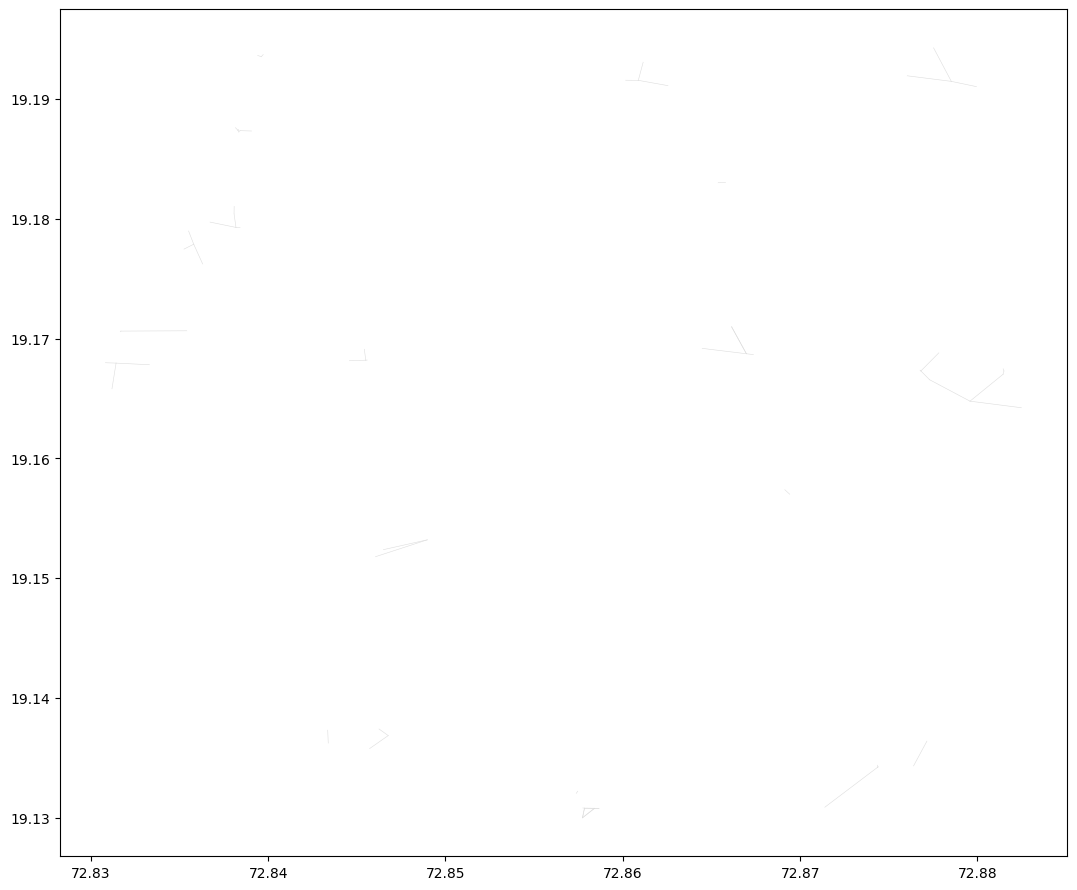

In [ ]:
# ─── Final evaluation on held-out location pairs ──────────────────────────────
# Evaluate the trained policy on 9 NEW pairs not seen during training.
# Uses deterministic (greedy) actions to measure generalisation.

best_path = f'{CKPT_DIR}/best.pt'
if os.path.exists(best_path):
    sac.load(best_path); print(f'Loaded {best_path}')
else:
    print('No best.pt — using latest in-memory weights')

# Pick held-out pairs: pairs not used in any epoch (or last epoch's pairs as proxy)
used_in_training = set()
for sched in EPOCH_SCHEDULE:
    for p in sched: used_in_training.add(p)
held_out = [p for p in ALL_LOC_PAIRS if p not in used_in_training]
if len(held_out) < N_AGENTS:
    # Fall back to last epoch's pairs if everything was covered
    held_out = EPOCH_SCHEDULE[-1]
    print(f'All pairs used in training; evaluating on last-epoch pairs.')
else:
    held_out = held_out[:N_AGENTS]
    print(f'Evaluating on {len(held_out)} held-out pairs (not seen during training).')

EVAL_AGENTS = build_agents_for_epoch('EVAL', held_out)
EVAL_AGENTS = [ag for ag in EVAL_AGENTS if ag.get('astar_path') is not None]
eval_envs = []
# Build a compact eval subgraph from eval agents' A* + Yen paths
G_ss_eval, _ = build_epoch_subgraph(EVAL_AGENTS)
for ag in EVAL_AGENTS:
    ps = max(ASTAR_STEP_MULT * len(ag['astar_path']), MIN_MAX_STEPS)
    eval_envs.append(RouteEnv(G_ss_eval, G_geo, ag['src'], ag['dst'],
                               policy_steps=ps,
                               astar_edges_set=ag['astar_edges_set']))

def rollout_eval(env):
    s = env.reset(); m = env.action_mask()
    fallback_used = False
    while not env.done:
        a = sac.act(s, m, stochastic=False)
        s2, r, done, info = env.step(a); m = env.action_mask(); s = s2
        if info.get('force_fallback'):
            fallback_used = True; break
        if done: break
    if fallback_used and not env.done:
        fb_path = env.fire_fallback('eval_fallback')
        for (u, v, k) in fb_path:
            env._execute_edge(u, v, k, from_policy=False)
            if env.done: break
    return env.reached_by_policy, fallback_used, env.elapsed_sec, env.edges_taken

final_rows = []
for ag, env in zip(EVAL_AGENTS, eval_envs):
    reach_pol, fb, el, edges = rollout_eval(env)
    sac_min = el/60
    imp = 100*(ag['astar_flood_sec'] - el)/ag['astar_flood_sec']
    final_rows.append({
        'agent': ag['id'],
        'src': ag['src_name'], 'dst': ag['dst_name'],
        'dist_km': round(haversine_km(ag['src_xy'], ag['dst_xy']), 2),
        'astar_nom_min':    ag['astar_nom_sec']/60,
        'astar_flood_min':  ag['astar_flood_sec']/60,
        'sac_time_min':     sac_min,
        'reached_by_policy': reach_pol, 'used_fallback': fb,
        'total_steps': env.total_steps,
        'improvement_vs_flood_pct': imp,
    })

fdf = pd.DataFrame(final_rows)
print('\n── FINAL EVAL (deterministic policy, held-out pairs) ──')
print(fdf.to_string(index=False, float_format='%.2f'))
fdf.to_csv(f'{OUT_DIR}/final_eval.csv', index=False)

# Final visualisation
fig, ax = plt.subplots(figsize=(13, 11))
eval_epoch_edges = set(e for ag in EVAL_AGENTS for e in ag['astar_path'])
_draw_background(ax, show_flood=True, epoch_edges=eval_epoch_edges)
_draw_landmark_labels(ax)
legend_handles = []
for ag, env in zip(EVAL_AGENTS, eval_envs):
    if env.edges_taken: _draw_route(ax, env.edges_taken, ag['color'], lw=2.5)
    _draw_markers(ax, ag['src_xy'], ag['dst_xy'], ag['color'])
    sac_min = env.elapsed_sec/60
    status = 'P' if env.reached_by_policy else ('F' if env.fallback_fired else '?')
    legend_handles.append(Line2D(
        [0],[0], color=ag['color'], lw=2.5,
        label=f"[{status}] {ag['src_name'].split()[0]}→{ag['dst_name'].split()[0]}: "
              f"SAC {sac_min:.1f} | floodA* {ag['astar_flood_sec']/60:.1f} min"))
legend_handles.append(Line2D([0],[0], color='#d62728', lw=1.2, linestyle='--',
                             label='flood edges'))
ax.set_title('FINAL EVAL — deterministic SAC on held-out pairs (● src, ★ dst)\n'
             'Trained on 21-landmark permutations, generalising to unseen routes',
             fontsize=10)
ax.legend(handles=legend_handles, loc='lower right', fontsize=7)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/final_sac_routes.png', dpi=120, bbox_inches='tight')
plt.close(fig)

imp = fdf['improvement_vs_flood_pct']
policy_only = fdf['reached_by_policy'].sum()
print(f'\nMean improvement vs flooded A*: {imp.mean():.1f}%  '
      f'(policy-only reach: {policy_only}/{len(EVAL_AGENTS)})')
print(f'Saved final viz → {OUT_DIR}/final_sac_routes.png')
